## Setup

In [1]:
import torch
from nnsight import LanguageModel

In [2]:
model_name = "meta-llama/Llama-3.3-70B-Instruct"

model = LanguageModel(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True
)

In [3]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 8192)
    (layers): ModuleList(
      (0-79): 80 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=8192, out_features=8192, bias=False)
          (k_proj): Linear(in_features=8192, out_features=1024, bias=False)
          (v_proj): Linear(in_features=8192, out_features=1024, bias=False)
          (o_proj): Linear(in_features=8192, out_features=8192, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=8192, out_features=28672, bias=False)
          (up_proj): Linear(in_features=8192, out_features=28672, bias=False)
          (down_proj): Linear(in_features=28672, out_features=8192, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((8192,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((8192,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((8192,), eps=1e-05)
    (rotary_

In [ ]:
PROMPT_TEMPLATE = "Q: Which of the following entities has a profession in common with {}? {}.\nA:"

clean_subj = "Albert Einstein"
corrupt_subj = "Taylor Swift"

entity_list = ["Brad Pitt", "Isaac Newton", "Michael Jackson"]

clean_prompt = PROMPT_TEMPLATE.format(clean_subj, (", ").join(entity_list))
print("Clean Prompt:", clean_prompt, "\n")

corrupt_prompt = PROMPT_TEMPLATE.format(corrupt_subj, (", ").join(entity_list))
print("Corrupt Prompt:", corrupt_prompt)

Clean Prompt: Q: Which of the following entities has a profession in common with Albert Einstein? Brad Pitt, Isaac Newton, Michael Jackson.
A: 

Corrupt Prompt: Q: Which of the following entities has a profession in common with Taylor Swift? Brad Pitt, Isaac Newton, Michael Jackson.
A:


In [5]:
clean_target_token_id = model.tokenizer.encode(" Isaac", add_special_tokens=False)
corrupt_target_token_id = model.tokenizer.encode(" Michael", add_special_tokens=False)

In [6]:
with model.trace(corrupt_prompt):
    # Save the output logits
    logits = model.output.logits.save()

    # Save the logits for predicting the clean_target
    clean_target_logits_corrupt = model.output.logits[0][-1, clean_target_token_id].item().save()

# Show the corrupt prediction and logits
corrupt_target_logits = logits[0][-1, corrupt_target_token_id].item()
corrupt_prediction = logits.argmax(dim=-1)[:, -1]
corrupt_token_prediction = model.tokenizer.decode(corrupt_prediction)
print(f"{corrupt_token_prediction=}")
print(f"{corrupt_target_logits=}")

# Show the logits for the clean target on the corrupt run
print(f"{clean_target_logits_corrupt=}")

Loading checkpoint shards:   0%|          | 0/30 [00:00<?, ?it/s]

corrupt_token_prediction=' Michael'
corrupt_target_logits=20.03125
clean_target_logits_corrupt=16.375


## Patching the MLP Layers

The MLP's job is to process information at each token position independently. Patching its output tests the hypothesis that a specific token's representation (e.g., "Einstein") is being enriched with features (e.g., "is a physicist") at a certain layer.

Now, instead of caching the entire layer's output, we'll target the output of the MLP sub-layer.

We can interpret this as telling us that the feed-forward/nonlinear feature write from this layer is necessary/sufficient (depending on if we're doing denoising vs. noising) for the behavior? This helps us separate MLP effects from attention effects in the layer.



In [10]:
clean_mlp_activations = []
with model.trace(clean_prompt):
    for l in range(model.config.num_hidden_layers):
        mlp_output = model.model.layers[l].mlp.output[0].save()
        clean_mlp_activations.append(mlp_output)
    clean_target_logits = model.output.logits[0][-1, clean_target_token_id].item().save()
print(f"{clean_target_logits=}")
print(f"{len(clean_mlp_activations)=}")

clean_target_logits=20.0625
len(clean_mlp_activations)=80


In [14]:
total_logit_diff = clean_target_logits - clean_target_logits_corrupt
print(f"Baseline logit difference (clean - corrupt): {total_logit_diff}")

NameError: name 'clean_target_logits' is not defined

In [13]:
clean_input_ids = model.tokenizer.encode(clean_prompt)
corrupt_input_ids = model.tokenizer.encode(corrupt_prompt)

assert len(clean_input_ids) == len(corrupt_input_ids)
print(len(corrupt_input_ids))

28


In [ ]:
from tqdm import trange

window_size = 5
num_layers = model.config.num_hidden_layers

windowed_mlp_results = []
for window_start_l in trange(num_layers - window_size + 1):
    patch_at_token = []
    for t in range(len(clean_input_ids)):

        # Single forward pass for the entire window
        with model.trace(corrupt_prompt):

            # Apply the patch for all layers within this window
            for l_offset in range(window_size):
                l_in_window = window_start_l + l_offset

                model.model.layers[l_in_window].mlp.output[0][t] = clean_mlp_activations[l_in_window][t]

            # Get the final logits after all 5 patches are in place
            patched_logits = model.output.logits[0].save()

            # Get the logits for the clean target
            patched_target_logits = patched_logits[-1, clean_target_token_id].item().save()

            # Calculate the logit difference
            logit_diff = patched_target_logits - clean_target_logits_corrupt

            # Normalize the logit difference
            if total_logit_diff == 0:
                normalized_score = 0.0
            else:
                normalized_score = logit_diff / total_logit_diff

            normalized_score = normalized_score.save()

        # Print the layer, token, and logit difference
        print(f"L{window_start_l}, T{t}, LD={normalized_score}")

        # Append the token to our list of logit differences at the current layer
        patch_at_token.append(normalized_score)
    
    # Append each layer's logit differences list to our overall list of lists
    windowed_mlp_results.append(patch_at_token)


#print(f"\\nPatched activations shape: {len(patched_activations)} layers x {len(patched_activations[0])} tokens")

  0%|          | 0/76 [00:00<?, ?it/s]

L0, T0, LD=0.0
L0, T1, LD=0.0
L0, T2, LD=0.0
L0, T3, LD=0.0
L0, T4, LD=0.0
L0, T5, LD=0.0
L0, T6, LD=0.0
L0, T7, LD=0.0
L0, T8, LD=0.0
L0, T9, LD=0.0
L0, T10, LD=0.0
L0, T11, LD=0.0
L0, T12, LD=0.0
L0, T13, LD=0.0
L0, T14, LD=-0.08898305084745763
L0, T15, LD=0.8813559322033898
L0, T16, LD=0.0
L0, T17, LD=-0.00847457627118644
L0, T18, LD=0.00423728813559322
L0, T19, LD=0.0
L0, T20, LD=0.0
L0, T21, LD=0.00423728813559322
L0, T22, LD=-0.00423728813559322
L0, T23, LD=0.0
L0, T24, LD=0.0
L0, T25, LD=0.0


  1%|▏         | 1/76 [00:03<04:36,  3.68s/it]

L0, T26, LD=0.0
L0, T27, LD=0.0
L0, T0, LD=0.0
L0, T1, LD=0.0
L0, T2, LD=0.0
L0, T3, LD=0.0
L0, T4, LD=0.0
L0, T5, LD=0.0
L0, T6, LD=0.0
L0, T7, LD=0.0
L0, T8, LD=0.0
L0, T9, LD=0.0
L0, T10, LD=0.0
L0, T11, LD=0.0
L0, T12, LD=0.0
L0, T13, LD=0.0
L0, T14, LD=-0.09745762711864407
L0, T15, LD=0.902542372881356
L0, T16, LD=-0.00847457627118644
L0, T17, LD=-0.00847457627118644
L0, T18, LD=-0.00423728813559322
L0, T19, LD=0.0
L0, T20, LD=0.0
L0, T21, LD=0.00423728813559322
L0, T22, LD=0.0
L0, T23, LD=0.0
L0, T24, LD=0.0
L0, T25, LD=-0.00847457627118644


  3%|▎         | 2/76 [00:07<04:32,  3.68s/it]

...

L0, T26, LD=-0.00423728813559322
L0, T27, LD=-0.08898305084745763
L0, T0, LD=0.0
L0, T1, LD=0.0
L0, T2, LD=0.0
L0, T3, LD=0.0
L0, T4, LD=0.0
L0, T5, LD=0.0
L0, T6, LD=0.0
L0, T7, LD=0.0
L0, T8, LD=0.0
L0, T9, LD=0.0
L0, T10, LD=0.0
L0, T11, LD=0.0
L0, T12, LD=0.0
L0, T13, LD=0.0
L0, T14, LD=0.0
L0, T15, LD=0.00423728813559322
L0, T16, LD=0.012711864406779662
L0, T17, LD=0.00423728813559322
L0, T18, LD=0.0
L0, T19, LD=0.0
L0, T20, LD=-0.00847457627118644
L0, T21, LD=0.0
L0, T22, LD=0.0
L0, T23, LD=0.00847457627118644
L0, T24, LD=0.00423728813559322
L0, T25, LD=0.00847457627118644


 99%|█████████▊| 75/76 [04:41<00:03,  3.79s/it]

L0, T26, LD=0.0
L0, T27, LD=0.038135593220338986
L0, T0, LD=0.0
L0, T1, LD=0.0
L0, T2, LD=0.0
L0, T3, LD=0.0
L0, T4, LD=0.0
L0, T5, LD=0.0
L0, T6, LD=0.0
L0, T7, LD=0.0
L0, T8, LD=0.0
L0, T9, LD=0.0
L0, T10, LD=0.0
L0, T11, LD=0.0
L0, T12, LD=0.0
L0, T13, LD=0.0
L0, T14, LD=0.0
L0, T15, LD=0.00423728813559322
L0, T16, LD=0.00847457627118644
L0, T17, LD=0.0
L0, T18, LD=0.00423728813559322
L0, T19, LD=0.0
L0, T20, LD=-0.00847457627118644
L0, T21, LD=0.0
L0, T22, LD=0.0
L0, T23, LD=0.00423728813559322
L0, T24, LD=0.0
L0, T25, LD=-0.00423728813559322


100%|██████████| 76/76 [04:45<00:00,  3.75s/it]

L0, T26, LD=0.00423728813559322
L0, T27, LD=-0.4279661016949153


Scores shape after transpose: (28, 76)
Data range: min=-0.4280, max=1.0466


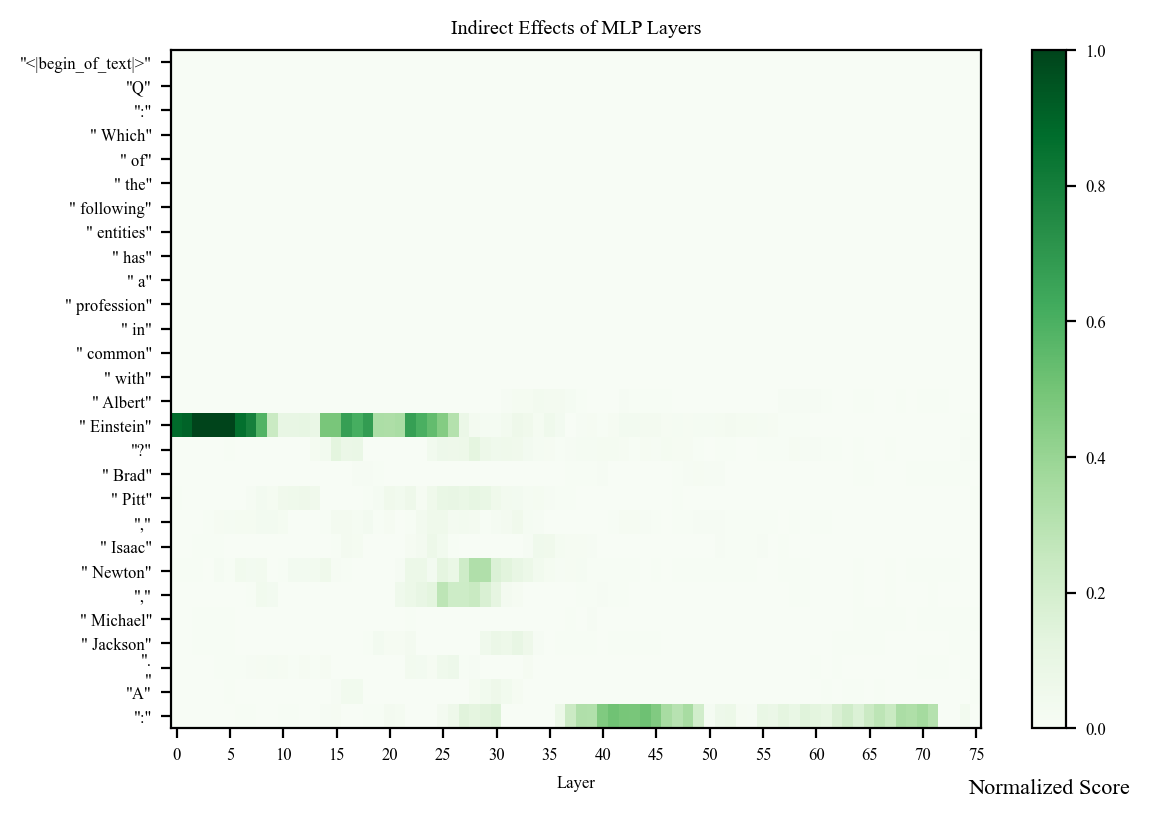

Data shape: (28, 76)
Number of tokens: 28


In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2D array: layers as rows, tokens as columns, then transpose
scores = np.array(windowed_mlp_results).T  # Transpose so tokens are rows, layers are columns
#scores = np.array(patched_activations).T  # Transpose so tokens are rows, layers are columns
print(f"Scores shape after transpose: {scores.shape}")

# Decode tokens to actual text
corrupt_tokens = [model.tokenizer.decode([token_id]) for token_id in corrupt_input_ids]
clean_tokens = [model.tokenizer.decode([token_id]) for token_id in clean_input_ids]

# Create token labels
tokens = []
for idx, (corrupt_tok, clean_tok) in enumerate(zip(corrupt_tokens, clean_tokens)):
    tokens.append(f'"{clean_tok}"')

# We will truncate to the 0 to 1 range, but this is the full actual range.
print(f"Data range: min={scores.min():.4f}, max={scores.max():.4f}")
scores = np.clip(scores, 0, 1)

plt.rcdefaults()
with plt.rc_context(
    rc={
        "font.family": "Times New Roman",
        "font.size": 6,
    }
):
    # Set figure size
    fig, ax = plt.subplots(
        figsize=(
            6,
            len(tokens) * 0.08 + 1.8
        ),
        dpi=200
    )
    
    # Scale range
    scale_kwargs = {
        "vmin": 0,
        "vmax": 1
    }

    heatmap = ax.pcolor(
        scores,
        cmap="Greens",
        **scale_kwargs,
    )

    ax.invert_yaxis()
    
    # Y-axis: token labels (rows)
    ax.set_yticks([0.5 + i for i in range(scores.shape[0])])  # Number of tokens
    ax.set_yticklabels(tokens)
    
    # X-axis: layer labels (columns)
    num_layers = scores.shape[1]
    tick_indices = np.arange(0, num_layers, 5)
    ax.set_xticks(tick_indices + 0.5)  # Number of layers
    ax.set_xticklabels(tick_indices)

    title = f"Indirect Effects of MLP Layers"
    ax.set_title(title)

    ax.set_xlabel("Layer")
    #ax.set_ylabel("Tokens")

    color_scale = plt.colorbar(heatmap)
    color_scale.ax.set_title(
        f"Normalized Score",
        y=-0.12,
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

print(f"Data shape: {scores.shape}")
print(f"Number of tokens: {len(tokens)}")



## Patching the Attention Layer


### Cache Clean Attention Activations

The input to `o_proj` contains the concatenated outputs of all heads for that layer.

In [16]:
clean_attn_activations = []
with model.trace(clean_prompt):
    for l in range(model.config.num_hidden_layers):
        # The input to the output projection combines all head outputs
        attn_outputs = model.model.layers[l].self_attn.output[0].save()
        clean_attn_activations.append(attn_outputs)
    clean_target_logits = model.output.logits[0][-1, clean_target_token_id].item().save()
print(f"{clean_target_logits=}")
print(f"{len(clean_attn_activations)=}") 


clean_target_logits=20.0625
len(clean_attn_activations)=80


In [17]:
total_logit_diff = clean_target_logits - clean_target_logits_corrupt
print(f"Baseline logit difference (clean - corrupt): {total_logit_diff}")

Baseline logit difference (clean - corrupt): 3.6875


In [44]:
clean_attn_activations[2][0][1].shape

80

In [48]:
from tqdm import trange

window_size = 5
num_layers = model.config.num_hidden_layers

windowed_attn_results = []

for window_start_l in trange(num_layers - window_size + 1):

    results_for_window = []
    for t in range(len(clean_input_ids)):

        # Single forward pass for entire window/token patch
        with model.trace(corrupt_prompt):

            #attn_out = model.model.layers[l_in_window].self_attn.output[0][0].save()
            
            # Apply the patch for all layers within this window
            for l_offset in range(window_size):
                l_in_window = window_start_l + l_offset

                model.model.layers[l_in_window].self_attn.output[0][0][t] = clean_attn_activations[l_in_window][0][t]

            patched_target_logits = model.output.logits[0, -1, clean_target_token_id].save()

            # Normalize and score
            logit_diff = patched_target_logits - clean_target_logits_corrupt

            # Normalize the logit difference
            if total_logit_diff == 0:
                normalized_score = 0.0
            else:
                normalized_score = logit_diff / total_logit_diff

            normalized_score = normalized_score.item().save()

        # Print the layer, token, and logit difference
        print(f"L{window_start_l}, T{t}, LD={normalized_score}")
        #print(f"{attn_out[0].shape=}")

        # Append the token to our list of logit differences at the current layer
        results_for_window.append(normalized_score)
    
    # Append each layer's logit differences list to our overall list of lists
    windowed_attn_results.append(results_for_window)


  0%|          | 0/76 [00:00<?, ?it/s]

L0, T0, LD=0.0
L0, T1, LD=0.0
L0, T2, LD=0.0
L0, T3, LD=0.0
L0, T4, LD=0.0
L0, T5, LD=0.0
L0, T6, LD=0.0
L0, T7, LD=0.0
L0, T8, LD=0.0
L0, T9, LD=0.0
L0, T10, LD=0.0
L0, T11, LD=0.0
L0, T12, LD=0.0
L0, T13, LD=0.0
L0, T14, LD=0.00847625732421875
L0, T15, LD=0.02117919921875
L0, T16, LD=-0.004238128662109375
L0, T17, LD=0.004238128662109375
L0, T18, LD=-0.004238128662109375
L0, T19, LD=0.0
L0, T20, LD=0.004238128662109375
L0, T21, LD=-0.004238128662109375
L0, T22, LD=0.0
L0, T23, LD=0.004238128662109375
L0, T24, LD=0.0
L0, T25, LD=0.0


  1%|▏         | 1/76 [00:03<04:47,  3.83s/it]

L0, T26, LD=-0.004238128662109375
L0, T27, LD=-0.00847625732421875
L1, T0, LD=0.0
L1, T1, LD=0.0
L1, T2, LD=0.0
L1, T3, LD=0.0
L1, T4, LD=0.0
L1, T5, LD=0.0
L1, T6, LD=0.0
L1, T7, LD=0.0
L1, T8, LD=0.0
L1, T9, LD=0.0
L1, T10, LD=0.0
L1, T11, LD=0.0
L1, T12, LD=0.0
L1, T13, LD=0.0
L1, T14, LD=0.00847625732421875
L1, T15, LD=-0.046600341796875
L1, T16, LD=-0.00847625732421875
L1, T17, LD=0.00847625732421875
L1, T18, LD=-0.004238128662109375
L1, T19, LD=-0.004238128662109375
L1, T20, LD=0.004238128662109375
L1, T21, LD=-0.004238128662109375
L1, T22, LD=0.004238128662109375
L1, T23, LD=0.004238128662109375
L1, T24, LD=0.0
L1, T25, LD=-0.004238128662109375


  3%|▎         | 2/76 [00:07<04:57,  4.02s/it]

...

L73, T27, LD=0.004238128662109375
L74, T0, LD=0.0
L74, T1, LD=0.0
L74, T2, LD=0.0
L74, T3, LD=0.0
L74, T4, LD=0.0
L74, T5, LD=0.0
L74, T6, LD=0.0
L74, T7, LD=0.0
L74, T8, LD=0.0
L74, T9, LD=0.0
L74, T10, LD=0.0
L74, T11, LD=0.0
L74, T12, LD=0.0
L74, T13, LD=0.0
L74, T14, LD=-0.004238128662109375
L74, T15, LD=0.004238128662109375
L74, T16, LD=0.0
L74, T17, LD=0.0127105712890625
L74, T18, LD=0.004238128662109375
L74, T19, LD=-0.004238128662109375
L74, T20, LD=-0.004238128662109375
L74, T21, LD=0.0
L74, T22, LD=0.0
L74, T23, LD=0.004238128662109375
L74, T24, LD=0.0
L74, T25, LD=0.0296630859375
L74, T26, LD=-0.004238128662109375


 99%|█████████▊| 75/76 [04:52<00:03,  3.89s/it]

L74, T27, LD=0.11016845703125
L75, T0, LD=0.0
L75, T1, LD=0.0
L75, T2, LD=0.0
L75, T3, LD=0.0
L75, T4, LD=0.0
L75, T5, LD=0.0
L75, T6, LD=0.0
L75, T7, LD=0.0
L75, T8, LD=0.0
L75, T9, LD=0.0
L75, T10, LD=0.0
L75, T11, LD=0.0
L75, T12, LD=0.0
L75, T13, LD=0.0
L75, T14, LD=0.0
L75, T15, LD=0.004238128662109375
L75, T16, LD=0.0
L75, T17, LD=0.0
L75, T18, LD=0.0
L75, T19, LD=0.0
L75, T20, LD=0.0
L75, T21, LD=0.0
L75, T22, LD=0.0
L75, T23, LD=0.0
L75, T24, LD=0.0
L75, T25, LD=0.004238128662109375
L75, T26, LD=0.004238128662109375


100%|██████████| 76/76 [04:56<00:00,  3.91s/it]

L75, T27, LD=0.13134765625


Scores shape after transpose: (28, 76)
Data range: min=-0.7627, max=1.1182


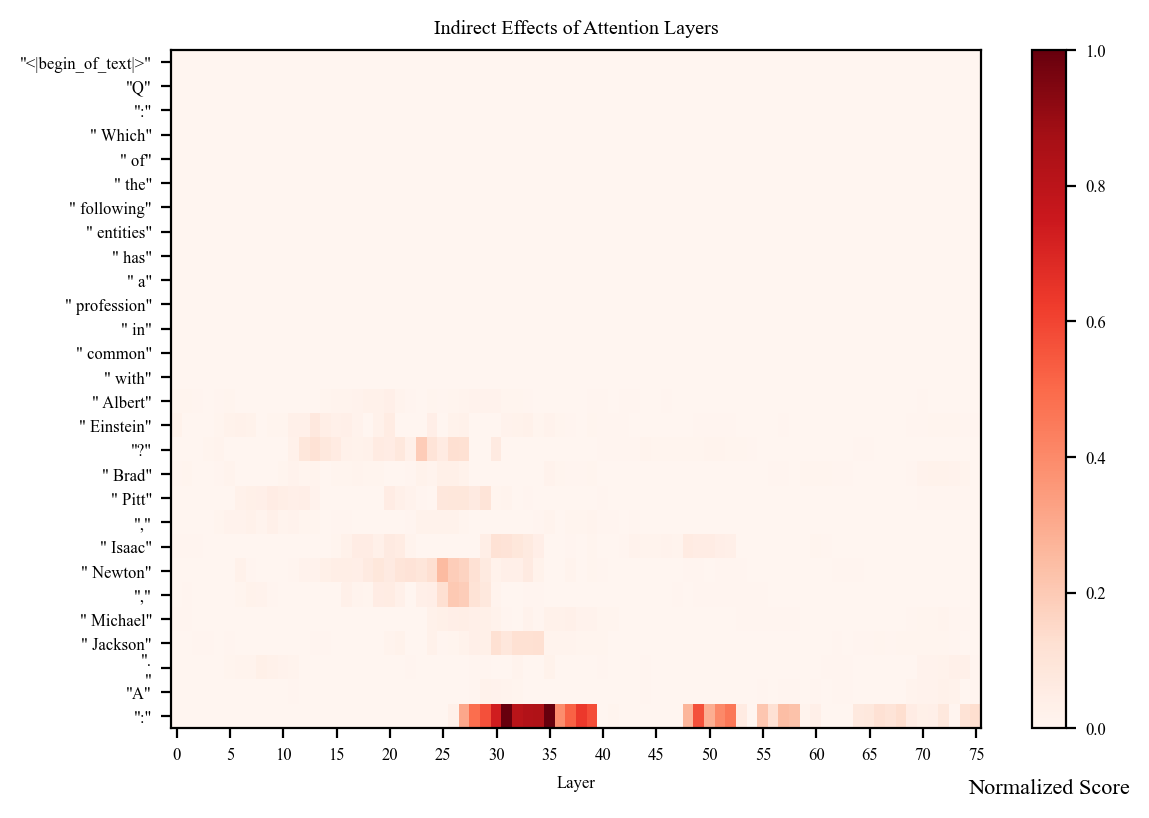

Data shape: (28, 76)
Number of tokens: 28


In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2D array: layers as rows, tokens as columns, then transpose
scores = np.array(windowed_attn_results).T  # Transpose so tokens are rows, layers are columns
#scores = np.array(patched_activations).T  # Transpose so tokens are rows, layers are columns
print(f"Scores shape after transpose: {scores.shape}")

# Decode tokens to actual text
corrupt_tokens = [model.tokenizer.decode([token_id]) for token_id in corrupt_input_ids]
clean_tokens = [model.tokenizer.decode([token_id]) for token_id in clean_input_ids]

# Create token labels
tokens = []
for idx, (corrupt_tok, clean_tok) in enumerate(zip(corrupt_tokens, clean_tokens)):
    tokens.append(f'"{clean_tok}"')

# We will truncate to the 0 to 1 range, but this is the full actual range.
print(f"Data range: min={scores.min():.4f}, max={scores.max():.4f}")
scores = np.clip(scores, 0, 1)

plt.rcdefaults()
with plt.rc_context(
    rc={
        "font.family": "Times New Roman",
        "font.size": 6,
    }
):
    # Set figure size
    fig, ax = plt.subplots(
        figsize=(
            6,
            len(tokens) * 0.08 + 1.8
        ),
        dpi=200
    )
    
    # Scale range
    scale_kwargs = {
        "vmin": 0,
        "vmax": 1
    }

    heatmap = ax.pcolor(
        scores,
        cmap="Reds",
        **scale_kwargs,
    )

    ax.invert_yaxis()
    
    # Y-axis: token labels (rows)
    ax.set_yticks([0.5 + i for i in range(scores.shape[0])])  # Number of tokens
    ax.set_yticklabels(tokens)
    
    # X-axis: layer labels (columns)
    num_layers = scores.shape[1]
    tick_indices = np.arange(0, num_layers, 5)
    ax.set_xticks(tick_indices + 0.5)  # Number of layers
    ax.set_xticklabels(tick_indices)

    title = f"Indirect Effects of Attention Layers"
    ax.set_title(title)

    ax.set_xlabel("Layer")
    #ax.set_ylabel("Tokens")

    color_scale = plt.colorbar(heatmap)
    color_scale.ax.set_title(
        f"Normalized Score",
        y=-0.12,
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

print(f"Data shape: {scores.shape}")
print(f"Number of tokens: {len(tokens)}")

